# ⚡ match_dos_v2 — Notebook PARAMETRIZADO por subtipo

## Cómo usar este notebook

1. Cambia el valor de `SUBTIPO_DOS` en la **CELDA 0** a uno de: `'TCP'`, `'UDP'`, `'SYN'`, `'HTTP'`.
2. **Run All**. Se guardarán los 4 CSVs comunes en `MuestrasComunes/DoS-{SUBTIPO}/`.
3. Repite para los otros 3 subtipos (reiniciando el kernel entre ejecuciones).
4. Al final, ejecuta la **CELDA 6 (UNIÓN)** UNA SOLA VEZ tras tener los 4 subtipos hechos. Junta los 4 CSVs comunes de cada herramienta en un único conjunto `DoS` en `MuestrasComunes/DoS/`.

## Cambios respecto a Mirai

- **`OFFSET_HORAS = 2`** (verano CEST, porque DoS se capturó en julio-agosto 2022). En Mirai era 1 porque era invierno.
- **Sin `reconstruir_ip`** (era exclusivo de Mirai).
- **Filtrado por subtipo con `glob`** en lugar de cargar todos los CSVs de la carpeta. Esto hace innecesario el sampling de Tshark que se usaba en Mirai.

In [19]:
# ============================================================
# CELDA 0 — IMPORTS Y PARÁMETROS GLOBALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ─── PARÁMETROS — CAMBIAR AQUÍ ENTRE EJECUCIONES ─────────────
SUBTIPO_DOS  = 'HTTP'   # Opciones: 'TCP', 'UDP', 'SYN', 'HTTP'
OFFSET_HORAS = 2       # DoS = verano 2022 → UTC+2 (CEST)
# ──────────────────────────────────────────────────────────────

assert SUBTIPO_DOS in ('TCP', 'UDP', 'SYN', 'HTTP'), \
    f"SUBTIPO_DOS debe ser TCP/UDP/SYN/HTTP, no '{SUBTIPO_DOS}'"

print(f'✓ Imports OK')
print(f'  pandas:       {pd.__version__}')
print(f'  numpy:        {np.__version__}')
print()
print(f'═══════════════════════════════════════════════')
print(f'  PROCESANDO SUBTIPO: DoS-{SUBTIPO_DOS}')
print(f'═══════════════════════════════════════════════')
print(f'  OFFSET_HORAS: {OFFSET_HORAS}h (verano CEST)')

✓ Imports OK
  pandas:       2.2.0
  numpy:        1.26.4

═══════════════════════════════════════════════
  PROCESANDO SUBTIPO: DoS-HTTP
═══════════════════════════════════════════════
  OFFSET_HORAS: 2h (verano CEST)


# CICFlowMeter

In [20]:
# ============================================================
# CELDA 1.1 — CARGA DE CIC (filtrado por subtipo)
# ============================================================

RUTA_CIC = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DoS')
print(f'Ruta CIC: {RUTA_CIC}')
print(f'Existe:   {RUTA_CIC.exists()}')
print()

# Filtrar por subtipo: 'TCP' → '*TCP*.csv', 'HTTP' → '*HTTP*.csv' (coge los 2 de HTTP)
csv_files = sorted(RUTA_CIC.glob(f'*{SUBTIPO_DOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DOS}*.csv')
print(f'CSVs encontrados para {SUBTIPO_DOS}: {len(csv_files)}')

if not csv_files:
    raise FileNotFoundError(f'No se encontraron CSVs con patrón *{SUBTIPO_DOS}*.csv en: {RUTA_CIC}')

dfs = []
for f in csv_files:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen'] = f.stem
    dfs.append(df_temp)
    print(f'  ✓ {f.name:50s} → {len(df_temp):>8,} filas')

df_cic = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print()
print(f'Shape total CIC ({SUBTIPO_DOS}): {df_cic.shape}')
print(f'NaNs totales:    {df_cic.isnull().sum().sum():,}')

Ruta CIC: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DoS
Existe:   True

Patrón glob: *HTTP*.csv
CSVs encontrados para HTTP: 2
  ✓ DoS-HTTP_Flood.pcap_Flow.csv                       →  932,513 filas
  ✓ DoS-HTTP_Flood1.pcap_Flow.csv                      →  710,231 filas

Shape total CIC (HTTP): (1642744, 85)
NaNs totales:    78,718


In [21]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC
# ============================================================

df_cic['Timestamp'] = (
    df_cic['Timestamp'].astype(str)
    .str.replace(' p. m.', ' PM', regex=False)
    .str.replace(' a. m.', ' AM', regex=False)
    .str.strip()
)
df_cic['Timestamp'] = pd.to_datetime(
    df_cic['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)

nat_count = df_cic['Timestamp'].isna().sum()
print(f'NaT en Timestamp: {nat_count}')
if nat_count > 0:
    df_cic = df_cic.dropna(subset=['Timestamp']).reset_index(drop=True)

df_cic['Protocol']      = pd.to_numeric(df_cic['Protocol'],      errors='coerce').fillna(0).astype(int)
df_cic['Src Port']      = pd.to_numeric(df_cic['Src Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Dst Port']      = pd.to_numeric(df_cic['Dst Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Flow Duration'] = pd.to_numeric(df_cic['Flow Duration'], errors='coerce')

print(f'\nShape CIC limpio: {df_cic.shape}')
print(f'\nRango temporal CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')
print(f'\nDistribución por protocolo:')
print(df_cic['Protocol'].value_counts().to_string())

NaT en Timestamp: 0

Shape CIC limpio: (1642744, 85)

Rango temporal CIC:
  Min: 2022-08-08 18:25:00
  Max: 2022-08-09 18:22:00

Distribución por protocolo:
Protocol
6     1616410
17      25512
0         822


In [22]:
# ============================================================
# CELDA 1.3 — KEY BASE Y KEY EXACT CIC
# ============================================================

df_cic['time_sec']    = df_cic['Timestamp'].dt.floor('s')
df_cic['flow_dur_ms'] = (df_cic['Flow Duration'] / 1000).round().astype('Int64')

df_cic['key_base'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str)
))
df_cic['key_exact'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str),
    df_cic['flow_dur_ms'].astype(str)
))

print(f'Shape CIC: {df_cic.shape}')
print(f'Claves base únicas: {df_cic["key_base"].nunique():,}')

Shape CIC: (1642744, 89)
Claves base únicas: 1,522,235


# NEMEA

In [23]:
# ============================================================
# CELDA 2.1 — CARGA DE NEMEA (filtrado por subtipo)
# ============================================================

RUTA_NEMEA = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DoS/DoS')
print(f'Ruta Nemea: {RUTA_NEMEA}')
print(f'Existe:     {RUTA_NEMEA.exists()}')
print()

# Filtrar por subtipo
csv_files_nemea = sorted(RUTA_NEMEA.glob(f'*{SUBTIPO_DOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DOS}*.csv')
print(f'CSVs Nemea encontrados: {len(csv_files_nemea)}')
for f in csv_files_nemea:
    print(f'  {f.name}')

if not csv_files_nemea:
    raise FileNotFoundError(f'No se encontraron CSVs Nemea con patrón *{SUBTIPO_DOS}* en: {RUTA_NEMEA}')

# Detectar columna de etiqueta desde la cabecera del primer fichero
col_etiqueta_nemea = pd.read_csv(csv_files_nemea[0], nrows=0).columns[-1]
print(f'\nColumna de etiqueta detectada: \'{col_etiqueta_nemea}\'')

dfs_nemea = []
for f in csv_files_nemea:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen_nemea'] = f.stem
    dfs_nemea.append(df_temp)
    print(f'  ✓ {f.name:45s} → {len(df_temp):>8,} filas')

df_nemea = pd.concat(dfs_nemea, ignore_index=True)
del dfs_nemea
gc.collect()

print()
print(f'Shape Nemea total: {df_nemea.shape}')
print(f'NaNs:              {df_nemea.isnull().sum().sum():,}')

Ruta Nemea: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DoS/DoS
Existe:     True

Patrón glob: *HTTP*.csv
CSVs Nemea encontrados: 1
  DoS_HTTP_Nemea.csv

Columna de etiqueta detectada: 'LABEL'
  ✓ DoS_HTTP_Nemea.csv                            →  282,398 filas

Shape Nemea total: (282398, 206)
NaNs:              1,129,441


In [24]:
# ============================================================
# CELDA 2.2 — LIMPIEZA Y NORMALIZACIÓN NEMEA
# OFFSET_HORAS = 2 (verano CEST)
# ============================================================

col_src_ip   = 'ipaddr SRC_IP'
col_dst_ip   = 'ipaddr DST_IP'
col_src_port = 'uint16 SRC_PORT'
col_dst_port = 'uint16 DST_PORT'
col_protocol = 'uint8 PROTOCOL'
col_t_first  = 'time TIME_FIRST'
col_t_last   = 'time TIME_LAST'

df_nemea[col_src_ip] = df_nemea[col_src_ip].astype(str).str.strip()
df_nemea[col_dst_ip] = df_nemea[col_dst_ip].astype(str).str.strip()

df_nemea['TIME_FIRST_limpio'] = df_nemea[col_t_first].astype(str).str.replace(',', '.', regex=False)
df_nemea['TIME_LAST_limpio']  = df_nemea[col_t_last].astype(str).str.replace(',', '.', regex=False)

df_nemea['TIME_FIRST_dt'] = pd.to_datetime(
    df_nemea['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)
df_nemea['TIME_LAST_dt'] = pd.to_datetime(
    df_nemea['TIME_LAST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)

df_nemea['TIME_FIRST_utc2'] = df_nemea['TIME_FIRST_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
df_nemea['TIME_LAST_utc2']  = df_nemea['TIME_LAST_dt']  + pd.Timedelta(hours=OFFSET_HORAS)

df_nemea['flow_dur_us'] = (
    (df_nemea['TIME_LAST_dt'] - df_nemea['TIME_FIRST_dt']).dt.total_seconds() * 1_000_000
).round().astype('Int64')
df_nemea['flow_dur_ms'] = (df_nemea['flow_dur_us'] / 1000).round().astype('Int64')

print(f'Shape Nemea limpio: {df_nemea.shape}')
print(f'\nRango temporal Nemea (UTC+{OFFSET_HORAS}):')
print(f"  Min: {df_nemea['TIME_FIRST_utc2'].min()}")
print(f"  Max: {df_nemea['TIME_FIRST_utc2'].max()}")
print(f'\nRango CIC (comprobar alineamiento):')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

Shape Nemea limpio: (282398, 214)

Rango temporal Nemea (UTC+2):
  Min: 2022-08-08 18:25:00.701385
  Max: 2022-08-09 18:22:00.967672

Rango CIC (comprobar alineamiento):
  Min: 2022-08-08 18:25:00
  Max: 2022-08-09 18:22:00


In [25]:
# ============================================================
# CELDA 2.3 — KEY BASE Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea['time_sec'] = df_nemea['TIME_FIRST_utc2'].dt.floor('s')

df_nemea['key_base_dir'] = list(zip(
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str)
))
df_nemea['key_base_inv'] = list(zip(
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str)
))
df_nemea['key_exact_dir'] = list(zip(
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))
df_nemea['key_exact_inv'] = list(zip(
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))

cic_keys_base  = set(df_cic['key_base'])
cic_keys_exact = set(df_cic['key_exact'])

nemea_base_dir  = set(df_nemea['key_base_dir'])
nemea_base_inv  = set(df_nemea['key_base_inv'])
nemea_exact_dir = set(df_nemea['key_exact_dir'])
nemea_exact_inv = set(df_nemea['key_exact_inv'])

match_nemea_base  = cic_keys_base  & (nemea_base_dir  | nemea_base_inv)
match_nemea_exact = cic_keys_exact & (nemea_exact_dir | nemea_exact_inv)

print('=' * 60)
print(f'MATCHING CIC ∩ NEMEA — DoS-{SUBTIPO_DOS}')
print('=' * 60)
print(f'  CIC total flujos:            {len(df_cic):,}')
print(f'  Nemea total flujos:          {len(df_nemea):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_nemea_base):,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_nemea_exact):,}  ({round(len(match_nemea_exact)/len(cic_keys_base)*100,2)}%)')

del nemea_base_dir, nemea_base_inv, nemea_exact_dir, nemea_exact_inv
df_nemea = df_nemea.drop(columns=['key_exact_dir', 'key_exact_inv'])
gc.collect()

MATCHING CIC ∩ NEMEA — DoS-HTTP
  CIC total flujos:            1,642,744
  Nemea total flujos:          282,398

  Match BASE (sin duración):   274,377  (18.02%)
  Match EXACTO (con dur. ms):  73,287  (4.81%)


25

# TSTAT

In [26]:
# ============================================================
# CELDA 3.1 — CARGA DE TSTAT (filtrado por subtipo)
# ============================================================

RUTA_TSTAT = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DoS')
print(f'Ruta Tstat: {RUTA_TSTAT}')
print(f'Existe:     {RUTA_TSTAT.exists()}')
print()

csv_files_tstat = sorted(RUTA_TSTAT.glob(f'*{SUBTIPO_DOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DOS}*.csv')
print(f'CSVs Tstat encontrados: {len(csv_files_tstat)}')

if not csv_files_tstat:
    raise FileNotFoundError(f'No se encontraron CSVs Tstat con patrón *{SUBTIPO_DOS}* en: {RUTA_TSTAT}')

dfs_tstat = []
for f in csv_files_tstat:
    df_temp = pd.read_csv(f, low_memory=False)
    dfs_tstat.append(df_temp)
    print(f'  ✓ {f.name:40s} → {len(df_temp):>8,} filas')

df_tstat = pd.concat(dfs_tstat, ignore_index=True)
del dfs_tstat
gc.collect()

print()
print(f'Shape total Tstat: {df_tstat.shape}')
print(f'\nDistribución por protocolo:')
print(df_tstat['protocolo'].value_counts().to_string())

Ruta Tstat: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DoS
Existe:     True

Patrón glob: *HTTP*.csv
CSVs Tstat encontrados: 1
  ✓ DoS-HTTP_Flood.csv                       →   63,308 filas

Shape total Tstat: (63308, 138)

Distribución por protocolo:
protocolo
TCP    52383
UDP    10925


In [27]:
# ============================================================
# CELDA 3.2 — LIMPIEZA Y SEPARACIÓN TCP/UDP TSTAT
# ============================================================

df_tcp_tstat = df_tstat[df_tstat['protocolo'] == 'TCP'].copy()
df_udp_tstat = df_tstat[df_tstat['protocolo'] == 'UDP'].copy()
print(f'TCP total: {len(df_tcp_tstat):,}  | UDP total: {len(df_udp_tstat):,}')
print()

# ── TCP
if len(df_tcp_tstat) > 0:
    df_tcp_tstat['first'] = pd.to_numeric(df_tcp_tstat['first'], errors='coerce')
    n_antes = len(df_tcp_tstat)
    df_tcp_tstat = df_tcp_tstat[df_tcp_tstat['first'] > 0].copy()
    print(f'TCP válidos (first>0): {len(df_tcp_tstat):,}  (eliminados: {n_antes-len(df_tcp_tstat):,})')

    df_tcp_tstat['first_dt']    = pd.to_datetime(df_tcp_tstat['first'], unit='ms', errors='coerce')
    df_tcp_tstat['first_utc2']  = df_tcp_tstat['first_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
    df_tcp_tstat['flow_dur_ms'] = df_tcp_tstat['durat'].round().astype('Int64')
    df_tcp_tstat['flow_dur_us'] = (df_tcp_tstat['durat'] * 1000).round().astype('Int64')
    df_tcp_tstat['proto_num']   = 6

# ── UDP
if len(df_udp_tstat) > 0:
    df_udp_tstat['c_first_abs'] = pd.to_numeric(df_udp_tstat['c_first_abs'], errors='coerce')
    n_antes = len(df_udp_tstat)
    df_udp_tstat = df_udp_tstat[df_udp_tstat['c_first_abs'] > 0].copy()
    print(f'UDP válidos (c_first_abs>0): {len(df_udp_tstat):,}  (eliminados: {n_antes-len(df_udp_tstat):,})')

    df_udp_tstat['first_dt']    = pd.to_datetime(df_udp_tstat['c_first_abs'], unit='ms', errors='coerce')
    df_udp_tstat['first_utc2']  = df_udp_tstat['first_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
    df_udp_tstat['c_durat']     = pd.to_numeric(df_udp_tstat['c_durat'], errors='coerce').fillna(0)
    df_udp_tstat['s_durat']     = pd.to_numeric(df_udp_tstat['s_durat'], errors='coerce').fillna(0)
    df_udp_tstat['flow_dur_ms'] = df_udp_tstat[['c_durat','s_durat']].max(axis=1).round().astype('Int64')
    df_udp_tstat['flow_dur_us'] = (df_udp_tstat['flow_dur_ms'] * 1000).round().astype('Int64')
    df_udp_tstat['proto_num']   = 17

del df_tstat
gc.collect()

TCP total: 52,383  | UDP total: 10,925

TCP válidos (first>0): 52,383  (eliminados: 0)
UDP válidos (c_first_abs>0): 10,925  (eliminados: 0)


0

In [28]:
# ============================================================
# CELDA 3.3 — BASE UNIFICADA TSTAT
# ============================================================

cols_base_tstat = ['c_ip','c_port','s_ip','s_port','proto_num',
                   'first_utc2','flow_dur_us','flow_dur_ms']

df_tstat_base = pd.concat([
    df_tcp_tstat[cols_base_tstat] if len(df_tcp_tstat) > 0 else pd.DataFrame(columns=cols_base_tstat),
    df_udp_tstat[cols_base_tstat] if len(df_udp_tstat) > 0 else pd.DataFrame(columns=cols_base_tstat),
], ignore_index=True)

df_tstat_base['time_sec'] = df_tstat_base['first_utc2'].dt.floor('s')

print(f'Shape Tstat base: {df_tstat_base.shape}')
print(f"  TCP: {(df_tstat_base['proto_num']==6).sum():,}")
print(f"  UDP: {(df_tstat_base['proto_num']==17).sum():,}")
print(f'\nRango temporal Tstat (UTC+{OFFSET_HORAS}):')
print(f"  Min: {df_tstat_base['time_sec'].min()}")
print(f"  Max: {df_tstat_base['time_sec'].max()}")

Shape Tstat base: (63308, 9)
  TCP: 52,383
  UDP: 10,925

Rango temporal Tstat (UTC+2):
  Min: 2022-08-08 18:25:00
  Max: 2022-08-09 15:45:42


In [29]:
# ============================================================
# CELDA 3.4 — KEY BASE Y MATCHING CIC ∩ TSTAT
# ============================================================

df_tstat_base['key_base_dir'] = list(zip(
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))
df_tstat_base['key_base_inv'] = list(zip(
    df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
    df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
    df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
))

df_tstat_dur = df_tstat_base[df_tstat_base['flow_dur_ms'] > 0].copy()
df_tstat_dur['key_exact_dir'] = list(zip(
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))
df_tstat_dur['key_exact_inv'] = list(zip(
    df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
    df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
    df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
    df_tstat_dur['flow_dur_ms'].astype(str)
))

tstat_base_keys  = set(df_tstat_base['key_base_dir']) | set(df_tstat_base['key_base_inv'])
tstat_exact_keys = set(df_tstat_dur['key_exact_dir']) | set(df_tstat_dur['key_exact_inv'])

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print('=' * 60)
print(f'MATCHING CIC ∩ TSTAT — DoS-{SUBTIPO_DOS}')
print('=' * 60)
print(f'  Tstat total flujos:          {len(df_tstat_base):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tstat_base):,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_tstat_exact):,}  ({round(len(match_tstat_exact)/len(cic_keys_base)*100,2)}%)')

del tstat_base_keys, tstat_exact_keys, df_tstat_dur
gc.collect()

MATCHING CIC ∩ TSTAT — DoS-HTTP
  Tstat total flujos:          63,308

  Match BASE (sin duración):   60,784  (3.99%)
  Match EXACTO (con dur. ms):  37,953  (2.49%)


0

# TSHARK

In [30]:
# ============================================================
# CELDA 4.1 — CARGA DE TSHARK (filtrado por subtipo, SIN sampling)
# ============================================================

RUTA_TSHARK = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DoS')
print(f'Ruta Tshark: {RUTA_TSHARK}')
print(f'Existe:      {RUTA_TSHARK.exists()}')
print()

csv_files_tshark = sorted(RUTA_TSHARK.glob(f'*{SUBTIPO_DOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DOS}*.csv')
print(f'CSVs encontrados: {len(csv_files_tshark)}')
print()

if not csv_files_tshark:
    raise FileNotFoundError(f'No se encontraron CSVs Tshark con patrón *{SUBTIPO_DOS}* en: {RUTA_TSHARK}')

dfs_tshark = []
for f in csv_files_tshark:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen'] = f.stem
    dfs_tshark.append(df_temp)
    print(f'  ✓ {f.name:40s} → {len(df_temp):>8,} filas')

df_tshark = pd.concat(dfs_tshark, ignore_index=True)
del dfs_tshark
gc.collect()

print()
print(f'Shape Tshark: {df_tshark.shape}')

Ruta Tshark: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DoS
Existe:      True

Patrón glob: *HTTP*.csv
CSVs encontrados: 1

  ✓ DoS-HTTP_Flood.csv                       →  774,311 filas

Shape Tshark: (774311, 65)


In [31]:
# ============================================================
# CELDA 4.2 — LIMPIEZA Y NORMALIZACIÓN TSHARK
# ============================================================

df_tshark['start_dt']    = pd.to_datetime(df_tshark['start_epoch'], unit='s', errors='coerce')
df_tshark['start_utc2']  = df_tshark['start_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
df_tshark['flow_dur_us'] = (df_tshark['flow_duration_s'] * 1_000_000).round().astype('Int64')
df_tshark['flow_dur_ms'] = (df_tshark['flow_duration_s'] * 1_000).round().astype('Int64')
df_tshark['proto_num']   = pd.to_numeric(df_tshark['proto_num'], errors='coerce').fillna(0).astype(int)

n_antes = len(df_tshark)
df_tshark = df_tshark.dropna(subset=['src_ip','dst_ip']).reset_index(drop=True)
print(f'Filas eliminadas sin IP: {n_antes - len(df_tshark):,}')

print(f'\nShape Tshark limpio: {df_tshark.shape}')
print(f'\nRango temporal Tshark (UTC+{OFFSET_HORAS}):')
print(f"  Min: {df_tshark['start_utc2'].min()}")
print(f"  Max: {df_tshark['start_utc2'].max()}")

Filas eliminadas sin IP: 0

Shape Tshark limpio: (774311, 69)

Rango temporal Tshark (UTC+2):
  Min: 2022-08-08 18:25:00.701385021
  Max: 2022-08-09 15:45:43.140188932


In [32]:
# ============================================================
# CELDA 4.3 — KEY BASE Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark['time_sec'] = df_tshark['start_utc2'].dt.floor('s')

df_tshark['key_base_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_base_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_exact_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))
df_tshark['key_exact_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))

tshark_base_keys  = set(df_tshark['key_base_dir']) | set(df_tshark['key_base_inv'])
tshark_exact_keys = set(df_tshark['key_exact_dir']) | set(df_tshark['key_exact_inv'])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print('=' * 60)
print(f'MATCHING CIC ∩ TSHARK — DoS-{SUBTIPO_DOS}')
print('=' * 60)
print(f'  Tshark total flujos:         {len(df_tshark):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tshark_base):,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_tshark_exact):,}  ({round(len(match_tshark_exact)/len(cic_keys_base)*100,2)}%)')

del tshark_base_keys, tshark_exact_keys
df_tshark = df_tshark.drop(columns=['key_exact_dir', 'key_exact_inv'])
gc.collect()

MATCHING CIC ∩ TSHARK — DoS-HTTP
  Tshark total flujos:         774,311

  Match BASE (sin duración):   755,152  (49.61%)
  Match EXACTO (con dur. ms):  654,924  (43.02%)


25

# Intersección las 4

In [33]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print('=' * 60)
print(f'INTERSECCIÓN 4 HERRAMIENTAS — DoS-{SUBTIPO_DOS}')
print('=' * 60)
print(f'  CIC total claves:              {len(cic_keys_base):>8,}')
print(f'  CIC ∩ Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC ∩ Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)')
print(f'  CIC ∩ Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/len(cic_keys_base)*100,2)}%)')
print(f'  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/len(cic_keys_base)*100,2)}%)')
print()
print(f'  Flujos extra al quitar dur.:   {len(base_4)-len(exact_4):>8,}')

INTERSECCIÓN 4 HERRAMIENTAS — DoS-HTTP
  CIC total claves:              1,522,235
  CIC ∩ Nemea  (base):            274,377  (18.02%)
  CIC ∩ Tstat  (base):             60,784  (3.99%)
  CIC ∩ Tshark (base):            755,152  (49.61%)

  COMUNES 4 (base, sin dur.):      56,915  (3.74%)
  COMUNES 4 (exacto, con dur.):     8,846  (0.58%)

  Flujos extra al quitar dur.:     48,069


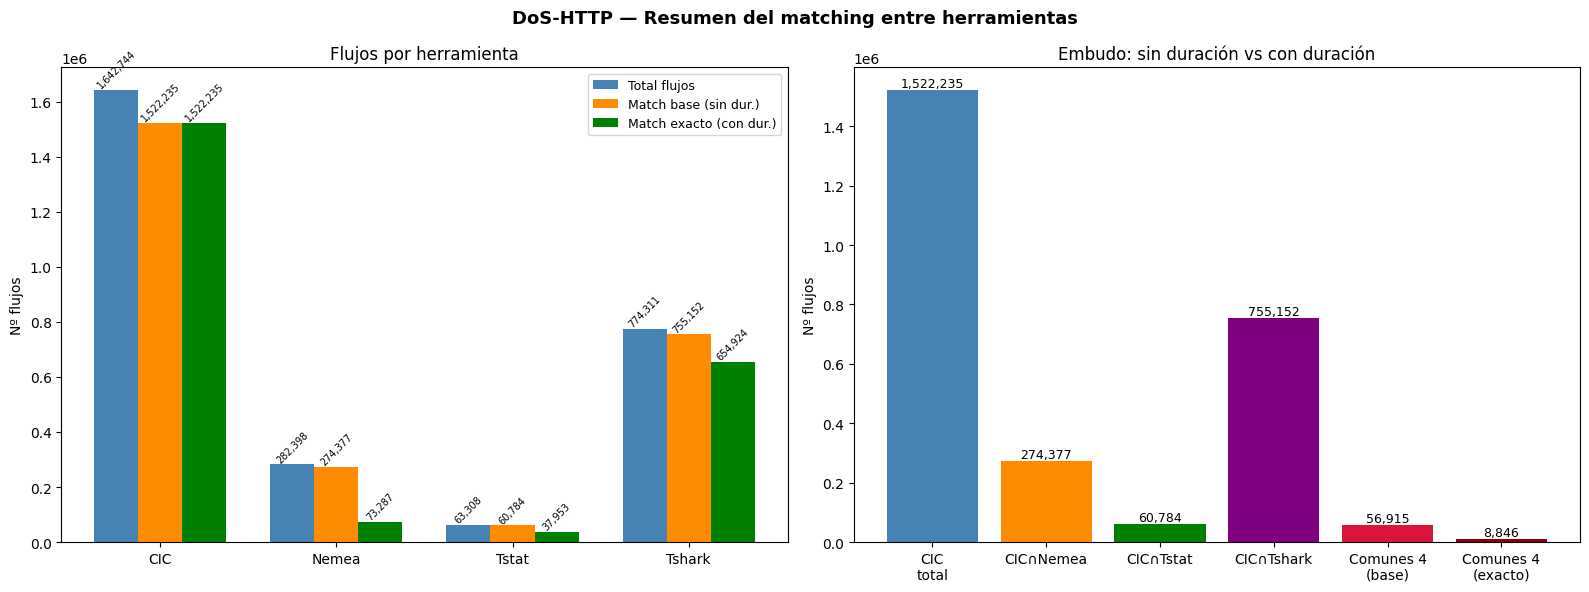

In [34]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'DoS-{SUBTIPO_DOS} — Resumen del matching entre herramientas',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
herramientas = ['CIC', 'Nemea', 'Tstat', 'Tshark']
totales = [len(df_cic), len(df_nemea), len(df_tstat_base), len(df_tshark)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, width = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - width, totales, width, label='Total flujos',            color='steelblue')
b2 = ax1.bar(x,         base,    width, label='Match base (sin dur.)',   color='darkorange')
b3 = ax1.bar(x + width, exactos, width, label='Match exacto (con dur.)', color='green')
ax1.set_title('Flujos por herramienta')
ax1.set_ylabel('Nº flujos')
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:,}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ['CIC\ntotal','CIC∩Nemea','CIC∩Tstat','CIC∩Tshark',
           'Comunes 4\n(base)','Comunes 4\n(exacto)']
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
colors2 = ['steelblue','darkorange','green','purple','crimson','darkred']
bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title('Embudo: sin duración vs con duración')
ax2.set_ylabel('Nº flujos')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# CELDA 5.3 — EXTRACCIÓN FINAL: 4 CSVs CON TODAS LAS COLUMNAS
# Guarda en MuestrasComunes/DoS-{SUBTIPO}/
# ============================================================

OUTPUT_DIR = Path(f'/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS-{SUBTIPO_DOS}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLS_AUX_CIC = ['archivo_origen','time_sec','flow_dur_ms','key_base','key_exact']

COLS_AUX_NEMEA = ['TIME_FIRST_limpio','TIME_LAST_limpio',
                  'TIME_FIRST_dt','TIME_LAST_dt',
                  'TIME_FIRST_utc2','TIME_LAST_utc2',
                  'time_sec','flow_dur_us','flow_dur_ms',
                  'key_base_dir','key_base_inv','_key']

COLS_AUX_TSTAT = ['first_utc2','flow_dur_us','flow_dur_ms',
                  'time_sec','key_base_dir','key_base_inv',
                  '_key','proto_num','first_dt']

COLS_AUX_TSHARK = ['start_dt','start_utc2','flow_dur_us','flow_dur_ms',
                   'time_sec','key_base_dir','key_base_inv',
                   'proto_num','archivo_origen','_key']

# ── NEMEA: asignar _key según base_4
df_nemea['_key'] = None
df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), '_key'] = \
    df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), 'key_base_dir']
df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), '_key'] = \
    df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), 'key_base_inv']

# ── TSTAT: asignar _key según base_4
df_tstat_base['_key'] = None
df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), '_key'] = \
    df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), 'key_base_dir']
df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), '_key'] = \
    df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), 'key_base_inv']

# ── TSHARK: asignar _key según base_4
df_tshark['_key'] = None
df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), '_key'] = \
    df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), 'key_base_dir']
df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), '_key'] = \
    df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), 'key_base_inv']

# Calcular intersección real de claves presentes en las 4 herramientas
claves_nemea  = set(df_nemea[df_nemea['_key'].notna()]['_key'])
claves_tstat  = set(df_tstat_base[df_tstat_base['_key'].notna()]['_key'])
claves_tshark = set(df_tshark[df_tshark['_key'].notna()]['_key'])
claves_cic    = set(df_cic['key_base'])
claves_finales = claves_nemea & claves_tstat & claves_tshark & claves_cic

print(f'Claves comunes reales (en las 4): {len(claves_finales):,}')
print()

# Filtrar cada DataFrame por las claves finales y deduplicar
df_nemea_4 = df_nemea[df_nemea['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
df_nemea_4 = df_nemea_4.drop(columns=COLS_AUX_NEMEA, errors='ignore').reset_index(drop=True)
print(f'Nemea:  {len(df_nemea_4):,} filas')

df_tstat_full = pd.concat([df_tcp_tstat, df_udp_tstat], ignore_index=True)
df_tstat_full['_key'] = df_tstat_base['_key'].values
df_tstat_4 = df_tstat_full[df_tstat_full['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
df_tstat_4 = df_tstat_4.drop(columns=COLS_AUX_TSTAT, errors='ignore').reset_index(drop=True)
print(f'Tstat:  {len(df_tstat_4):,} filas')

df_tshark_4 = df_tshark[df_tshark['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
df_tshark_4 = df_tshark_4.drop(columns=COLS_AUX_TSHARK, errors='ignore').reset_index(drop=True)
print(f'Tshark: {len(df_tshark_4):,} filas')

df_cic_4 = df_cic[df_cic['key_base'].isin(claves_finales)].drop_duplicates(subset=['key_base']).copy()
df_cic_4 = df_cic_4.drop(columns=COLS_AUX_CIC, errors='ignore').reset_index(drop=True)
print(f'CIC:    {len(df_cic_4):,} filas')

# Guardar
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print('=' * 60)
print(f'RESULTADO FINAL — DoS-{SUBTIPO_DOS}')
print('=' * 60)
print(f'  CIC:    {len(df_cic_4):>6,} filas x {df_cic_4.shape[1]:>3} columnas')
print(f'  Nemea:  {len(df_nemea_4):>6,} filas x {df_nemea_4.shape[1]:>3} columnas')
print(f'  Tstat:  {len(df_tstat_4):>6,} filas x {df_tstat_4.shape[1]:>3} columnas')
print(f'  Tshark: {len(df_tshark_4):>6,} filas x {df_tshark_4.shape[1]:>3} columnas')
print(f'\n  Guardados en: {OUTPUT_DIR}')

if len(df_cic_4) == len(df_nemea_4) == len(df_tstat_4) == len(df_tshark_4):
    print(f'\n  ✓ VERIFICACIÓN CORRECTA — los 4 CSVs tienen {len(df_cic_4):,} flujos')
else:
    print(f'\n  ✗ Algún CSV no coincide → revisar')

Claves comunes reales (en las 4): 56,852

Nemea:  56,852 filas
Tstat:  56,852 filas
Tshark: 56,852 filas
CIC:    56,852 filas

RESULTADO FINAL — DoS-HTTP
  CIC:    56,852 filas x  84 columnas
  Nemea:  56,852 filas x 206 columnas
  Tstat:  56,852 filas x 138 columnas
  Tshark: 56,852 filas x  63 columnas

  Guardados en: /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS-HTTP

  ✓ VERIFICACIÓN CORRECTA — los 4 CSVs tienen 56,852 flujos


In [36]:
# ============================================================
# CELDA 5.4 — ESTANDARIZAR ETIQUETA A 'DoS' EN LOS 4 CSVs
# Independientemente del subtipo (TCP/UDP/SYN/HTTP), todos
# llevan la etiqueta unificada 'DoS' para el clasificador ML.
# ============================================================

LABEL_MAP = {
    'CIC':    (df_cic_4,    'Label'),
    'Nemea':  (df_nemea_4,  col_etiqueta_nemea),
    'Tshark': (df_tshark_4, 'category'),
    'Tstat':  (df_tstat_4,  'etiqueta'),
}

for nombre, (df, col) in LABEL_MAP.items():
    if col in df.columns:
        antes = df[col].value_counts().to_dict()
        df[col] = 'DoS'
        print(f'{nombre:8s} | {col:20s} → antes: {antes}')
        print(f'{"":8s} |                       → ahora: {df[col].unique().tolist()}')
    else:
        print(f'  ⚠ {nombre}: columna \'{col}\' no encontrada')

# Sobreescribir con etiquetas actualizadas
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print(f'✓ Etiquetas actualizadas y CSVs guardados en {OUTPUT_DIR}')
print(f'\n⏭  Siguiente paso: cambia SUBTIPO_DOS en CELDA 0,')
print(f'   reinicia kernel (Restart) y vuelve a ejecutar Run All.')

CIC      | Label                → antes: {'DoS-HTTP_Flood': 56852}
         |                       → ahora: ['DoS']
Nemea    | LABEL                → antes: {'DoS': 56852}
         |                       → ahora: ['DoS']
Tshark   | category             → antes: {'DoS-HTTP_Flood': 56852}
         |                       → ahora: ['DoS']
Tstat    | etiqueta             → antes: {'DoS-HTTP_Flood': 56852}
         |                       → ahora: ['DoS']

✓ Etiquetas actualizadas y CSVs guardados en /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS-HTTP

⏭  Siguiente paso: cambia SUBTIPO_DOS en CELDA 0,
   reinicia kernel (Restart) y vuelve a ejecutar Run All.


---

# 🔗 CELDA 6 — UNIÓN FINAL (ejecutar SOLO al terminar los 4 subtipos)

Esta celda se ejecuta **una única vez**, después de haber lanzado el notebook con `SUBTIPO_DOS = 'TCP'`, `'UDP'`, `'SYN'` y `'HTTP'`. Lee los 4 CSVs comunes de cada herramienta, los concatena, y guarda el resultado final en `MuestrasComunes/DoS/` con la etiqueta unificada `DoS`.

**Reinicia el kernel antes de ejecutarla** para tener RAM limpia. No hace falta ejecutar las celdas anteriores.

In [1]:
# ============================================================
# CELDA 6 — UNIÓN DE LOS 4 SUBTIPOS EN UN ÚNICO CONJUNTO DoS
# Ejecutar SOLO al final, cuando los 4 subtipos estén procesados
# ============================================================
import pandas as pd
from pathlib import Path
import gc

BASE_MUESTRAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes')
OUTPUT_DOS    = BASE_MUESTRAS / 'DoS'
OUTPUT_DOS.mkdir(parents=True, exist_ok=True)

SUBTIPOS = ['TCP', 'UDP', 'SYN', 'HTTP']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

resumen = {}

for herr in HERRAMIENTAS:
    print(f'\n{"="*60}')
    print(f'  UNIENDO {herr}')
    print(f'{"="*60}')

    dfs = []
    for sub in SUBTIPOS:
        ruta = BASE_MUESTRAS / f'DoS-{sub}' / f'{herr}_comunes.csv'
        if not ruta.exists():
            print(f'  ⚠ NO existe {ruta} — saltando subtipo {sub}')
            continue
        df_temp = pd.read_csv(ruta, low_memory=False)
        df_temp['subtipo_dos'] = sub
        dfs.append(df_temp)
        print(f'  ✓ DoS-{sub:5s} → {len(df_temp):>8,} filas')

    if not dfs:
        print(f'  ✗ No hay CSVs para {herr}, saltando.')
        continue

    df_union = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()

    salida = OUTPUT_DOS / f'{herr}_comunes.csv'
    df_union.to_csv(salida, index=False)
    resumen[herr] = len(df_union)
    print(f'  → TOTAL {herr}: {len(df_union):,} filas → {salida}')

    del df_union
    gc.collect()

print(f'\n{"="*60}')
print(f'  RESUMEN FINAL — clase DoS unificada')
print(f'{"="*60}')
for herr, n in resumen.items():
    print(f'  {herr:8s}: {n:>8,} filas')

if len(set(resumen.values())) == 1:
    n_dos = list(resumen.values())[0]
    print(f'\n  ✓ Las 4 herramientas tienen el mismo nº de filas: {n_dos:,}')
    print(f'  ✓ Guardado en: {OUTPUT_DOS}')
    print(f'\n  Comparativa con la minoritaria:')
    print(f'    Web (minoritaria actual): 3,481')
    print(f'    DoS (nueva clase):        {n_dos:,}')
    if n_dos > 3481:
        print(f'    → ✓ DoS supera a Web por {n_dos-3481:,} flujos')
else:
    print(f'\n  ⚠ Los CSVs no coinciden en filas, revisar')


  UNIENDO CIC
  ✓ DoS-TCP   →      817 filas
  ✓ DoS-UDP   →   66,950 filas
  ✓ DoS-SYN   →   78,297 filas
  ✓ DoS-HTTP  →   56,852 filas
  → TOTAL CIC: 202,916 filas → /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS/CIC_comunes.csv

  UNIENDO Nemea
  ✓ DoS-TCP   →      817 filas
  ✓ DoS-UDP   →   66,950 filas
  ✓ DoS-SYN   →   78,297 filas
  ✓ DoS-HTTP  →   56,852 filas
  → TOTAL Nemea: 202,916 filas → /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS/Nemea_comunes.csv

  UNIENDO Tstat
  ✓ DoS-TCP   →      817 filas
  ✓ DoS-UDP   →   66,950 filas
  ✓ DoS-SYN   →   78,297 filas
  ✓ DoS-HTTP  →   56,852 filas
  → TOTAL Tstat: 202,916 filas → /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS/Tstat_comunes.csv

  UNIENDO Tshark
  ✓ DoS-TCP   →      817 filas
  ✓ DoS-UDP   →   66,950 filas
  ✓ DoS-SYN   →   78,297 filas
  ✓ DoS-HTTP  →   56,852 filas
  → TOTAL Tshark: 202,916 filas → /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS/Tshark_comunes.csv

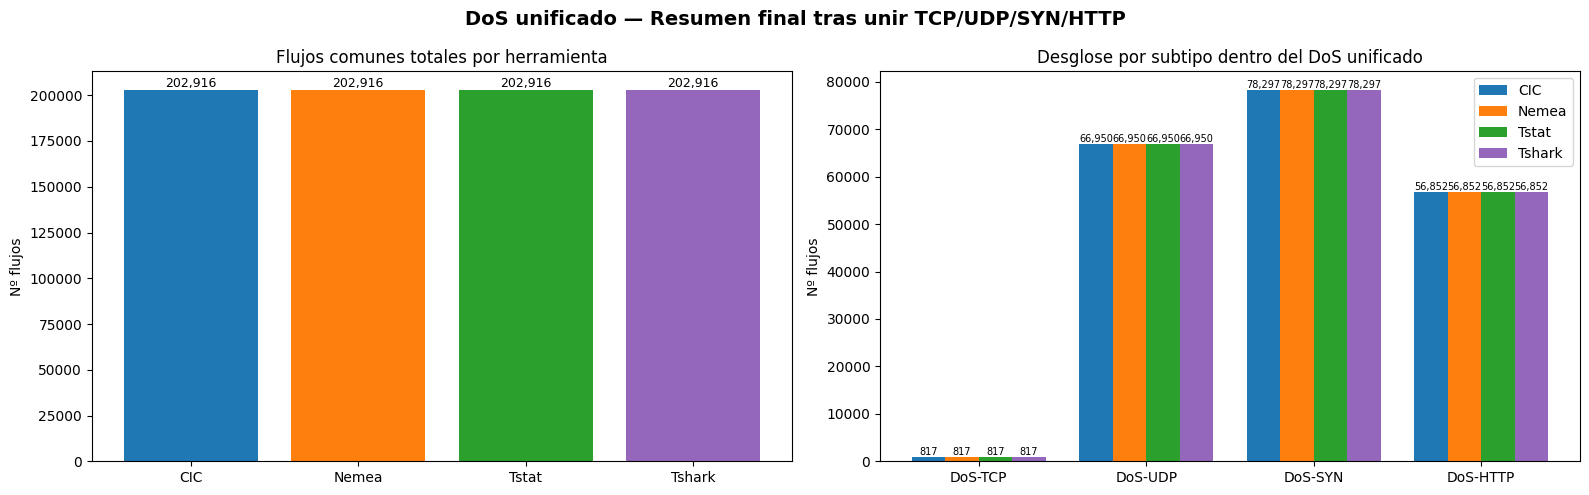


  ✓ Gráfica guardada en: /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DoS/resumen_DoS_unificado.png


In [2]:
# ============================================================
# CELDA 7 — GRÁFICA FINAL DoS UNIFICADO
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Releer los CSVs unificados para sacar el desglose por subtipo
totales_herr = {}
desglose = {}  # {herr: {sub: n_filas}}

for herr in HERRAMIENTAS:
    ruta = OUTPUT_DOS / f'{herr}_comunes.csv'
    if not ruta.exists():
        continue
    df_tmp = pd.read_csv(ruta, low_memory=False, usecols=['subtipo_dos'])
    totales_herr[herr] = len(df_tmp)
    desglose[herr] = df_tmp['subtipo_dos'].value_counts().to_dict()
    del df_tmp
    gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DoS unificado — Resumen final tras unir TCP/UDP/SYN/HTTP',
             fontsize=14, fontweight='bold')

# --- Subplot 1: total por herramienta ---
ax1 = axes[0]
herrs   = list(totales_herr.keys())
valores = [totales_herr[h] for h in herrs]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
bars = ax1.bar(herrs, valores, color=colores[:len(herrs)])
ax1.set_title('Flujos comunes totales por herramienta')
ax1.set_ylabel('Nº flujos')
for b, v in zip(bars, valores):
    ax1.text(b.get_x() + b.get_width()/2, v, f'{v:,}',
             ha='center', va='bottom', fontsize=9)

# --- Subplot 2: desglose por subtipo (barras agrupadas) ---
ax2 = axes[1]
subs = SUBTIPOS
x = np.arange(len(subs))
ancho = 0.2
colores_sub = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
for i, herr in enumerate(herrs):
    vals = [desglose[herr].get(s, 0) for s in subs]
    barras = ax2.bar(x + i*ancho, vals, ancho, label=herr, color=colores_sub[i])
    for b, v in zip(barras, vals):
        ax2.text(b.get_x() + b.get_width()/2, v, f'{v:,}',
                 ha='center', va='bottom', fontsize=7, rotation=0)
ax2.set_title('Desglose por subtipo dentro del DoS unificado')
ax2.set_xticks(x + ancho*1.5)
ax2.set_xticklabels([f'DoS-{s}' for s in subs])
ax2.set_ylabel('Nº flujos')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DOS / 'resumen_DoS_unificado.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  ✓ Gráfica guardada en: {OUTPUT_DOS / "resumen_DoS_unificado.png"}')